# Capa Bronce — Clustering de Urbanización (CDMX)


## Objetivo
Esta capa tiene como finalidad almacenar los datos en su estado original (raw),
preservando la información proveniente de las fuentes oficiales sin aplicar
transformaciones de negocio.

## Fuentes de datos
- DENUE (Directorio Estadístico Nacional de Unidades Económicas)
- ITER (Información de localidades INEGI)
- Información geoespacial (shapefiles)
- Datos de establecimientos comerciales

## Resultado esperado
Generar tablas en formato Delta que sirvan como entrada para la capa Plata.


Lectura del archivo CSV

**header=True:**
Utiliza la primera fila como nombres de columnas.

**inferSchema=True:**
Intenta detectar automáticamente los tipos de datos (String, Integer, Double, etc.).

**load():**
Ruta donde se encuentra almacenado el archivo fuente.

In [0]:
# Importar datos ITER

df_ITER = (spark.read
      .format("csv")
      .option("header", "true")        # Usa la primera fila como nombres de columnas
      .option("inferSchema", "true")   # Detecta automáticamente tipos de datos
      .load("/Workspace/ITER_CDMX.csv"))

df_ITER.show(5)   # Muestra las primeras 5 filas


+-------+----------------+---+--------------------+----+--------------------+-------------------+------------------+-------+-------+-------+-------+------+-------+-------+-------+---------+---------+-------+---------+---------+--------+----------+----------+--------+----------+----------+--------+----------+----------+------+-------+-------+------+--------+--------+------+--------+--------+-------+---------+---------+-------+---------+---------+-------+---------+---------+---------+--------+----------+----------+-------+-------+--------+---------+------+-------+-------+------+-------+-------+-------+---------+---------+-------+---------+---------+-------+---------+---------+-------+---------+---------+-------+---------+---------+-------+---------+---------+-------+---------+---------+-------+---------+---------+-------+---------+---------+-------+---------+---------+-------+---------+---------+-------+---------+---------+-------+---------+---------+-------+---------+---------+-------+-

In [0]:
#"" Importar datos de bancos

df_bancos = (spark.read
      .format("csv")
      .option("header", "true")        # Usa la primera fila como nombres de columnas
      .option("inferSchema", "true")   # Detecta automáticamente tipos de datos
      .load("/Workspace/denue_inegi_Bancos_.csv"))


# Importar datos de comida

df_comida = (spark.read
      .format("csv")
      .option("header", "true")        # Usa la primera fila como nombres de columnas
      .option("inferSchema", "true")   # Detecta automáticamente tipos de datos
      .load("/Workspace/denue_inegi_comida.csv"))

# Importar datos de corporativos

df_corporativos = (spark.read
      .format("csv")
      .option("header", "true")        # Usa la primera fila como nombres de columnas
      .option("inferSchema", "true")   # Detecta automáticamente tipos de datos
      .load("/Workspace/denue_inegi_corporativos_.csv"))

# Importar datos de deportes

df_deportes = (spark.read
      .format("csv")
      .option("header", "true")        # Usa la primera fila como nombres de columnas
      .option("inferSchema", "true")   # Detecta automáticamente tipos de datos
      .load("/Workspace/denue_inegi_deportes_.csv"))

# Importar datos de negocios

df_negocios = (spark.read
      .format("csv")
      .option("header", "true")        # Usa la primera fila como nombres de columnas
      .option("inferSchema", "true")   # Detecta automáticamente tipos de datos
      .load("/Workspace/denue_inegi_negocios_.csv"))

# Importar datos de corporativos

df_negocios_tiendas = (spark.read
      .format("csv")
      .option("header", "true")        # Usa la primera fila como nombres de columnas
      .option("inferSchema", "true")   # Detecta automáticamente tipos de datos
      .load("/Workspace/denue_inegi_Negocios_Tiendas_.csv"))

# Importar datos de restaurantes

df_restaurantes = (spark.read
      .format("csv")
      .option("header", "true")        # Usa la primera fila como nombres de columnas
      .option("inferSchema", "true")   # Detecta automáticamente tipos de datos
      .load("/Workspace/denue_inegi_restaurantes_.csv"))

# Importar datos de tiendas

df_tiendas = (spark.read
      .format("csv")
      .option("header", "true")        # Usa la primera fila como nombres de columnas
      .option("inferSchema", "true")   # Detecta automáticamente tipos de datos
      .load("/Workspace/denue_inegi_tiendas_.csv"))

# Importar datos de transporte

df_transporte = (spark.read
      .format("csv")
      .option("header", "true")        # Usa la primera fila como nombres de columnas
      .option("inferSchema", "true")   # Detecta automáticamente tipos de datos
      .load("/Workspace/denue_inegi_transporte_.csv"))

In [0]:
# ITER
df_ITER.write.format("delta").mode("overwrite").saveAsTable("bronze_ITER")

# Bancos
df_bancos.write.format("delta").mode("overwrite").saveAsTable("bronze_bancos")

# Comida
df_comida.write.format("delta").mode("overwrite").saveAsTable("bronze_comida")

# Corporativos
df_corporativos.write.format("delta").mode("overwrite").saveAsTable("bronze_corporativos")

# Deportes
df_deportes.write.format("delta").mode("overwrite").saveAsTable("bronze_deportes")

# Negocios
df_negocios.write.format("delta").mode("overwrite").saveAsTable("bronze_negocios")

# Negocios Tiendas
df_negocios_tiendas.write.format("delta").mode("overwrite").saveAsTable("bronze_negocios_tiendas")

# Restaurantes
df_restaurantes.write.format("delta").mode("overwrite").saveAsTable("bronze_restaurantes")

# Tiendas
df_tiendas.write.format("delta").mode("overwrite").saveAsTable("bronze_tiendas")

# Transporte
df_transporte.write.format("delta").mode("overwrite").saveAsTable("bronze_transporte")


In [0]:
# Añadimos los archivos mun

%pip install geopandas shapely

import geopandas as gpd
from shapely import wkt

# 1. Cargar shapefile
gdf = gpd.read_file("/Workspace/09mun.shp")

# 2. Convertir geometría a WKT
gdf["geometry"] = gdf["geometry"].apply(lambda geom: geom.wkt)

# 3. Pasar a Spark DataFrame
df_bronze = spark.createDataFrame(gdf)

# 4. Guardar como tabla Delta en capa bronze
df_bronze.write.format("delta").mode("overwrite").saveAsTable("bronze_marco_geoestadistico")


Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


/home/spark-8a5215e3-c289-4e2d-b321-07/.ipykernel/303/command-7581140522623073-2236011808:12: UserWarning: Geometry column does not contain geometry.
  gdf["geometry"] = gdf["geometry"].apply(lambda geom: geom.wkt)


In [0]:

# La geometría se almacena como texto (WKT) para asegurar compatibilidad con Spark y formato Delta.
# Importamos AGEB de la CDMX

import geopandas as gpd

# 1. Cargar shapefile
gdf09a = gpd.read_file("/Workspace/09a.shp")

# 2. Convertir geometría a WKT (ANTES de Spark)
gdf09a["geometry"] = gdf09a["geometry"].apply(lambda x: x.wkt)

# 3. Crear Spark DataFrame
df_bronze = spark.createDataFrame(gdf09a)

# 4. Guardar en Delta
df_bronze.write.format("delta") \
    .mode("overwrite") \
    .saveAsTable("bronze_ageb")

/home/spark-8a5215e3-c289-4e2d-b321-07/.ipykernel/303/command-6653888220969212-2040487573:9: UserWarning: Geometry column does not contain geometry.
  gdf09a["geometry"] = gdf09a["geometry"].apply(lambda x: x.wkt)


<Axes: >

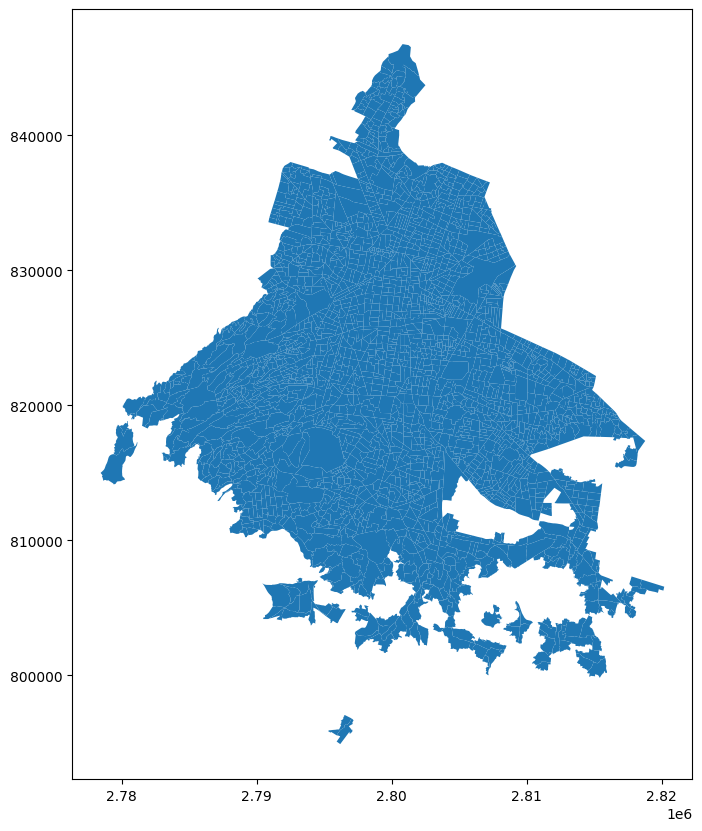

In [0]:
import geopandas as gpd

gdf09a = gpd.read_file("/Workspace/09a.shp")

gdf09a.plot(figsize=(10,10))

In [0]:
# Importamos manzanas de la CDMX

import geopandas as gpd

# 1. Cargar shapefile
gdf09m = gpd.read_file("/Workspace/09m.shp")

# 2. Convertir geometría a WKT (OBLIGATORIO para Spark)
gdf09m["geometry"] = gdf09m["geometry"].apply(lambda x: x.wkt)

# 3. Crear Spark DataFrame
df_bronze_manzanas = spark.createDataFrame(gdf09m)

# 4. Guardar en Delta Bronze
df_bronze_manzanas.write.format("delta") \
    .mode("overwrite") \
    .saveAsTable("bronze_manzanas")

/home/spark-8a5215e3-c289-4e2d-b321-07/.ipykernel/303/command-6653888220969213-1237247292:9: UserWarning: Geometry column does not contain geometry.
  gdf09m["geometry"] = gdf09m["geometry"].apply(lambda x: x.wkt)


<Axes: >

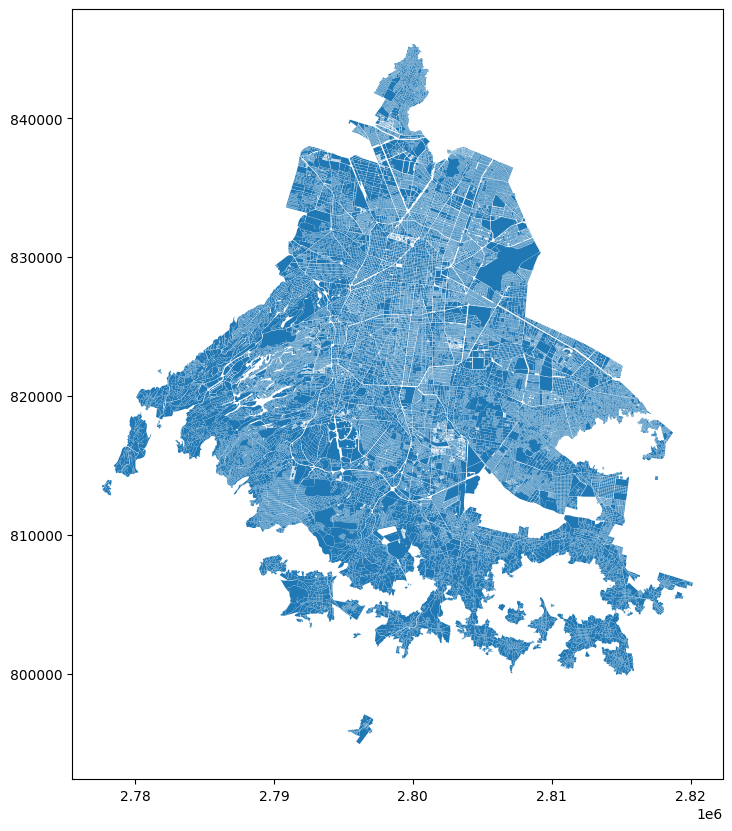

In [0]:
# Visualización del mapa

import geopandas as gpd

gdf09m = gpd.read_file("/Workspace/09m.shp")

gdf09m.plot(figsize=(10,10))

In [0]:
# Visualizar los datos del dataframe.

df_bronze.printSchema()
display(df_bronze.limit(5))

root
 |-- CVEGEO: string (nullable = true)
 |-- CVE_ENT: string (nullable = true)
 |-- CVE_MUN: string (nullable = true)
 |-- CVE_LOC: string (nullable = true)
 |-- CVE_AGEB: string (nullable = true)
 |-- geometry: string (nullable = true)



CVEGEO CVE_ENT CVE_MUN CVE_LOC CVE_AGEB geometry 0901000011716 09 010 0001 1716 POLYGON ((2787237.5414000005 816989.4607000016, 2787288.728 816977.6893000007, 2787290.579999998 816983.9450999983, 2787330.464299999 816976.4734999985, 2787333.2529999986 816968.4371999986, 2787386.850100003 816958.7107000016, 2787416.859099999 816949.8713000007, 2787448.919399999 816940.4274999984, 2787472.6125999987 816933.4492000006, 2787500.2343000025 816925.3117999993, 2787497.5270000026 816904.2228999995, 2787490.3407000005 816879.4811000004, 2787480.2676 816857.6506000012, 2787440.7657999992 816790.7485000007, 2787421.3862000033 816760.4827000014, 2787397.8456000015 816721.0865000002, 2787397.843999997 816721.0837999992, 2787378.8630999997 816692.1506000012, 2787369.579599999 816681.0337999985, 2787351.209899999 816661.6316, 2787336.222599998 816651.1565999985, 2787322.6950000003 816638.5089999996, 2787286.6137000024 816625.6279000007, 2787270.6350999996 816609.1079000011, 2787254.2475999966 816600.4853999987, 2787222.535700001 816573.6308999993, 2787205.307400003 816549.7756999992, 2787162.9258999974 816516.8425000012, 2787149.5913999975 816502.1429999992, 2787134.8154999986 816485.8570000008, 2787085.6074 816433.1022999994, 2787077.8122999966 816419.6094000004, 2787065.5974999964 816386.6598999985, 2787040.6523 816357.0843000002, 2787018.1635999978 816320.4484999999, 2786982.5041000023 816226.6997999996, 2786961.647 816178.5388000011, 2786953.1297999993 816127.5892999992, 2786945.5746000037 816112.8192999996, 2786897.395300001 816070.2566, 2786876.3039999977 816053.7232000008, 2786842.409699999 816010.4376000017, 2786842.3999999985 816010.4252000004, 2786833.5331000015 816016.9754000008, 2786828.9416000023 816020.9657000005, 2786819.0154 816042.4743000008, 2786812.2173999995 816072.8735999987, 2786809.5088 816084.3585000001, 2786808.0491999984 816101.1381999999, 2786805.6225000024 816135.0280999988, 2786805.4239000008 816142.7463000007, 2786806.3962000012 816160.8343000002, 2786811.0584999993 816185.2186999992, 2786818.277099997 816235.9677000009, 2786834.4032000005 816322.1301000006, 2786831.400200002 816356.7806999981, 2786822.3764000013 816387.5403999984, 2786814.8206999972 816410.1988000013, 2786813.805399999 816420.8326999992, 2786805.802199997 816453.8654000014, 2786805.811800003 816453.9015999995, 2786811.976599999 816477.1656000018, 2786829.3049999997 816517.6717000008, 2786860.6624 816571.1004999988, 2786887.7885999978 816606.5568999983, 2786903.6331999972 816634.8931000009, 2786932.6371000037 816695.3995000012, 2786947.8549999967 816721.8557000011, 2786956.3101999983 816735.3079999983, 2786965.3891000003 816746.887600001, 2787019.628899999 816803.0302999988, 2787044.2080999985 816835.6504999995, 2787045.2415999994 816847.2254999988, 2787069.216600001 816890.9976000004, 2787123.0144999996 816842.3552000001, 2787189.956699997 816897.3368000016, 2787215.5244999975 816932.3874999993, 2787234.6908000037 816981.6048000008, 2787237.5414000005 816989.4607000016)) 0901000012150 09 010 0001 2150 POLYGON ((2794154.458499998 823013.4442999996, 2794155.773699999 822998.506000001, 2794163.1845000014 822917.4384000003, 2794164.5408999994 822898.0916000009, 2794165.4909999967 822874.5062999986, 2794164.7893999964 822846.4560000002, 2794152.954599999 822719.2087999992, 2794142.3455 822719.8942000009, 2794133.410099998 822720.4406999983, 2794119.646300003 822721.2824000008, 2794010.4756999984 822731.7023000009, 2793938.0046000034 822737.5505999997, 2793884.128200002 822742.572900001, 2793811.1340000033 822748.1787, 2793738.706100002 822754.1867000014, 2793666.637500003 822760.2010000013, 2793677.374300003 822874.6317000017, 2793690.848899998 823048.9514000006, 2793762.708999999 823025.4576999992, 2793833.7668000013 823005.3346999995, 2793884.8334000036 822990.6942000017, 2793906.717500001 822984.5920999981, 2793972.9782999977 822964.9488999993, 2794022.8693000004 822951.691300001, 2793995.611100003 823031.9662999995, 2793989.647399999 823047.6603

In [0]:
spark.table("bronze_ITER").printSchema()

spark.table("bronze_bancos").printSchema()

root
 |-- ENTIDAD: integer (nullable = true)
 |-- NOM_ENT: string (nullable = true)
 |-- MUN: integer (nullable = true)
 |-- NOM_MUN: string (nullable = true)
 |-- LOC: integer (nullable = true)
 |-- NOM_LOC: string (nullable = true)
 |-- LONGITUD: string (nullable = true)
 |-- LATITUD: string (nullable = true)
 |-- ALTITUD: integer (nullable = true)
 |-- POBTOT: integer (nullable = true)
 |-- POBFEM: string (nullable = true)
 |-- POBMAS: string (nullable = true)
 |-- P_0A2: string (nullable = true)
 |-- P_0A2_F: string (nullable = true)
 |-- P_0A2_M: string (nullable = true)
 |-- P_3YMAS: string (nullable = true)
 |-- P_3YMAS_F: string (nullable = true)
 |-- P_3YMAS_M: string (nullable = true)
 |-- P_5YMAS: string (nullable = true)
 |-- P_5YMAS_F: string (nullable = true)
 |-- P_5YMAS_M: string (nullable = true)
 |-- P_12YMAS: string (nullable = true)
 |-- P_12YMAS_F: string (nullable = true)
 |-- P_12YMAS_M: string (nullable = true)
 |-- P_15YMAS: string (nullable = true)
 |-- P_15YM